In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [76]:
nu_param = 1.0
K = 2
L = 10
bs = np.linspace(0.0, 4.0, 100)
taus = np.zeros((len(bs), K**(L+1)-1))
indices = {}
indices[0] = np.arange(1)
for level in range(1, L + 1):
    indices[level] = np.arange(0, K**level) + indices[level - 1][-1] + 1
for step in range(1000):
    for level in range(L, 0, -1):
        lags_level = taus[:, indices[level]] - bs[:, np.newaxis]
        lags_level = lags_level.reshape((len(bs), K, -1))
        max_taus = np.max(np.maximum(lags_level, 0.0), axis=1)
        taus[:, indices[level - 1]] = max_taus + nu_param * np.random.exponential(size=(len(bs), K**(level - 1)))

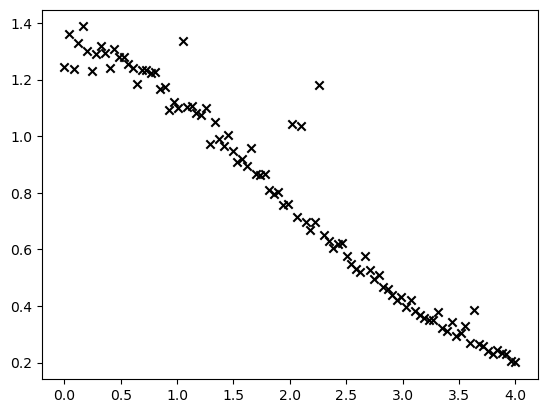

In [79]:
from scipy.stats import linregress
for b_idx in np.arange(0, len(bs)):
    hist, bin_edges = np.histogram(taus[b_idx,:], bins=50, density=True)
    #plt.scatter(bin_edges[:-1], hist, label=f'b={bs[b_idx]:.2f}')
    mask = bin_edges[:-1] > 1/nu_param
    mask = mask & (hist > 0)
    regr_res = linregress(bin_edges[:-1][mask], np.log(hist[mask]))
    plt.scatter(bs[b_idx], np.exp(bs[b_idx] * regr_res.slope)/(1+regr_res.slope), color='black', marker='x')

plt.show()